In [2]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from river import compose, datasets, metrics, preprocessing, anomaly
from sklearn.ensemble import IsolationForest


In [3]:

dataset = datasets.CreditCard().take(100)





In [4]:


model = compose.Pipeline(
    preprocessing.MinMaxScaler(),
    anomaly.HalfSpaceTrees()
)

auc = metrics.ROCAUC()

for x, y in datasets.CreditCard().take(2500):
    score = model.score_one(x)
    model.learn_one(x)
    auc.update(y, score)
    
auc

ROCAUC: 85.03%

In [5]:
for x, y in dataset:
    print(x)
    break

{'Time': 0.0, 'V1': -1.3598071336738, 'V2': -0.0727811733098497, 'V3': 2.53634673796914, 'V4': 1.37815522427443, 'V5': -0.338320769942518, 'V6': 0.462387777762292, 'V7': 0.239598554061257, 'V8': 0.0986979012610507, 'V9': 0.363786969611213, 'V10': 0.0907941719789316, 'V11': -0.551599533260813, 'V12': -0.617800855762348, 'V13': -0.991389847235408, 'V14': -0.311169353699879, 'V15': 1.46817697209427, 'V16': -0.470400525259478, 'V17': 0.207971241929242, 'V18': 0.0257905801985591, 'V19': 0.403992960255733, 'V20': 0.251412098239705, 'V21': -0.018306777944153, 'V22': 0.277837575558899, 'V23': -0.110473910188767, 'V24': 0.0669280749146731, 'V25': 0.128539358273528, 'V26': -0.189114843888824, 'V27': 0.133558376740387, 'V28': -0.0210530534538215, 'Amount': 149.62}


In [6]:
# Load 100 samples from the RiverML credit card dataset into a DataFrame
import pandas as pd
from river import datasets

dataset = datasets.CreditCard()

X, y = [], []
for i, (xi, yi) in enumerate(dataset):
    if i >= 100:
        break
    X.append(xi)
    y.append(yi)

df = pd.DataFrame(X)
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,64.0,-0.658305,0.406791,2.037461,-0.291298,0.147910,-0.350857,0.945373,-0.172560,0.025133,...,0.064133,-0.156096,-0.238805,0.089877,0.421195,-0.352487,0.074783,-0.094192,-0.092493,54.99
96,64.0,0.959602,0.370711,0.888613,2.343244,0.352491,1.365515,-0.277771,0.516053,-0.700929,...,-0.298405,-0.155547,-0.403239,0.356504,-0.696881,-0.198718,-0.220268,0.068546,0.020797,7.55
97,67.0,-0.653445,0.160225,1.592256,1.296832,0.997175,-0.343000,0.469937,-0.132470,-0.197794,...,0.225920,0.038363,0.336449,-0.014883,0.102959,-0.265322,-0.348637,0.011238,-0.049478,19.85
98,67.0,-1.494668,0.837241,2.628211,3.145414,-0.609098,0.258495,-0.012189,0.102136,-0.286164,...,-0.028352,-0.140047,0.355044,0.332720,0.718193,-0.219366,0.118927,-0.317486,-0.340783,28.28


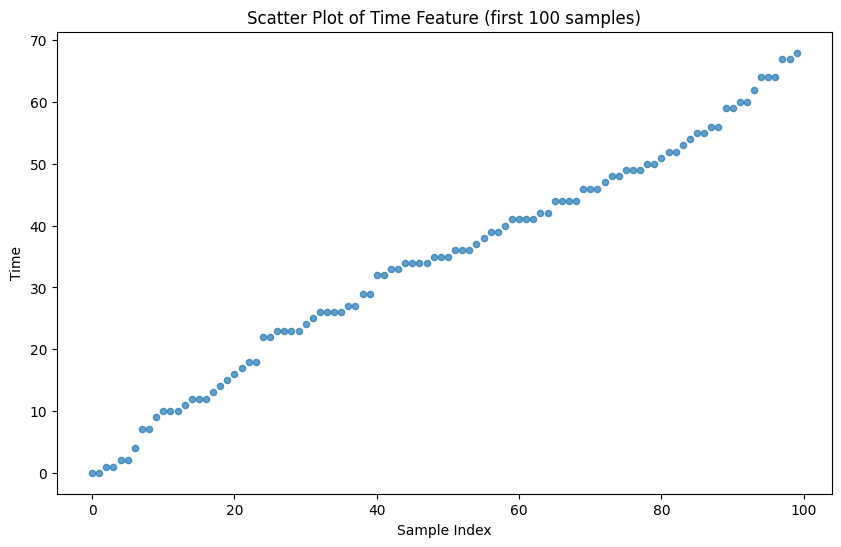

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(df)), df['Time'], s=20, alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Time')
plt.title('Scatter Plot of Time Feature (first 100 samples)')
plt.show()

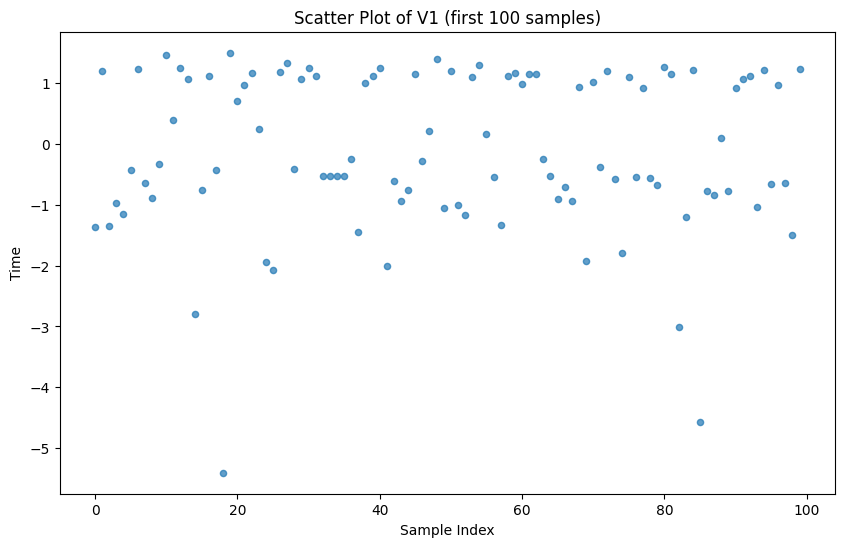

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(df)), df['V1'], s=20, alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Time')
plt.title('Scatter Plot of V1 (first 100 samples)')
plt.show()

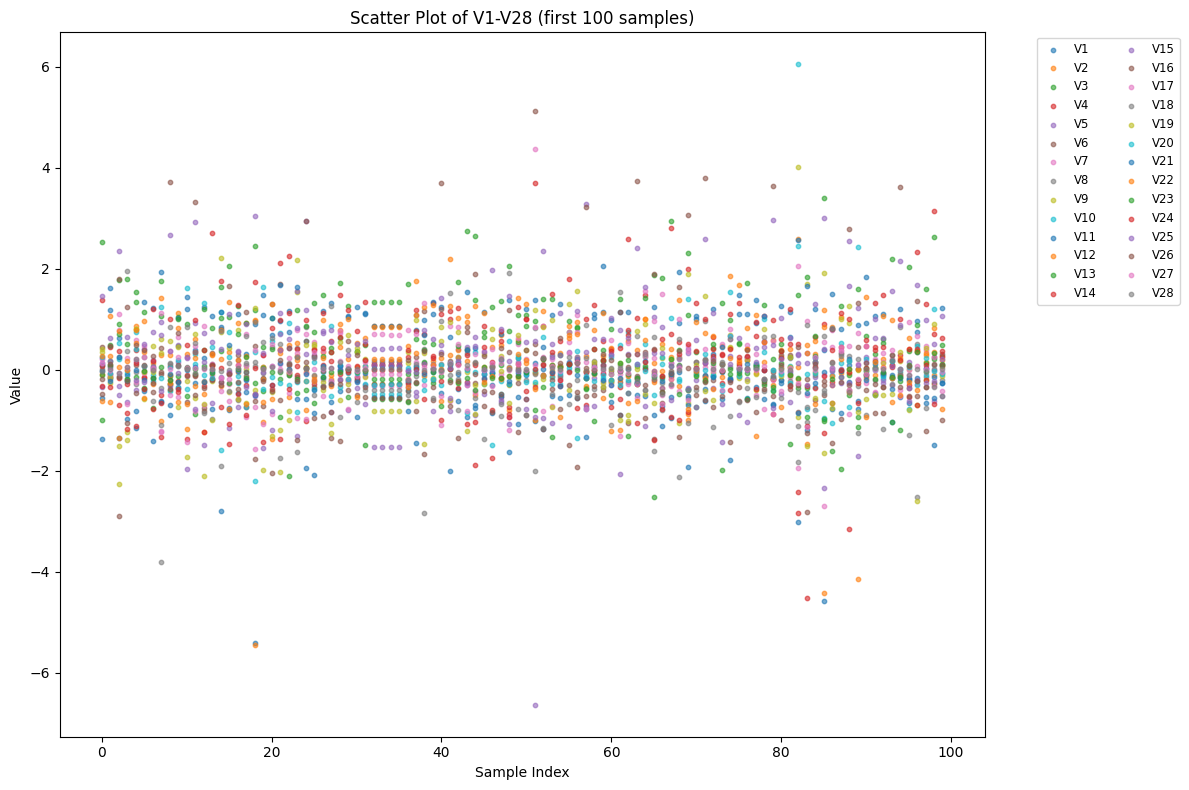

In [9]:
plt.figure(figsize=(12, 8))
for i in range(1, 29):
    plt.scatter(range(len(df)), df[f'V{i}'], s=10, label=f'V{i}', alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Scatter Plot of V1-V28 (first 100 samples)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()


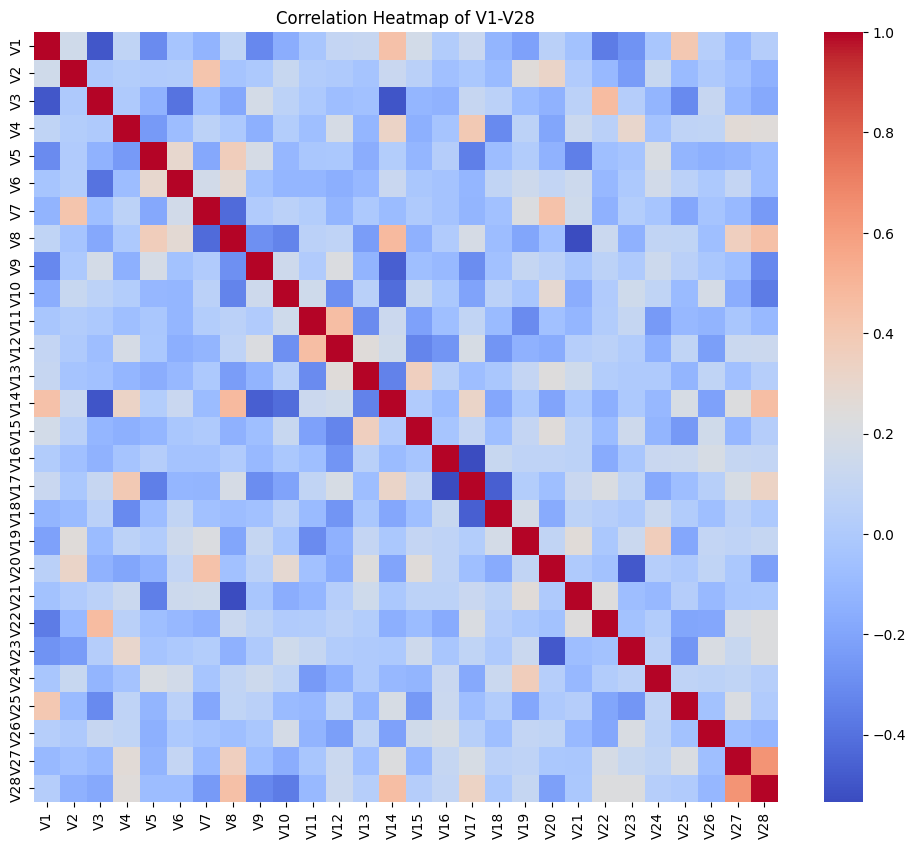

In [10]:
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(df[[f'V{i}' for i in range(1, 29)]].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of V1-V28')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
# Normal data: 100 points centered around (0, 0)
rng = np.random.RandomState(42)
X_normal = 0.3 * rng.randn(100, 2)
X_train = pd.DataFrame(X_normal, columns=['Feature_A', 'Feature_B'])

# Anomalies: 20 points spread out far from the center
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2) )
X_outliers = pd.DataFrame(X_outliers, columns=['Feature_A', 'Feature_B'])

# 2. Initialize the Model
model = IsolationForest(
    n_estimators=100, 
    contamination=0.5, 
    random_state=42
)

# 3. Fit the Model (Training)
model.fit(X_train)

# 4. Predict and Score
# Predict returns 1 for normal, -1 for anomaly
predictions = model.predict(X_outliers)
# Scores return the anomaly score (lower is more anomalous)
scores = model.decision_function(X_outliers)

# 5. Review Results
X_outliers['is_anomaly'] = predictions
X_outliers['anomaly_score'] = scores
print(X_outliers.head())

   Feature_A  Feature_B  is_anomaly  anomaly_score
0   3.018985   1.926149          -1      -0.266555
1   1.576126   1.619873          -1      -0.266555
2  -1.124071  -1.651265          -1      -0.272047
3   2.474889   2.480907          -1      -0.266555
4   2.936579   3.305924          -1      -0.266555
